Condition type: numeric
Condition values: [np.float64(0.0), np.float64(1.0)]
Sample shapes: (100000, 3) (100000, 3)


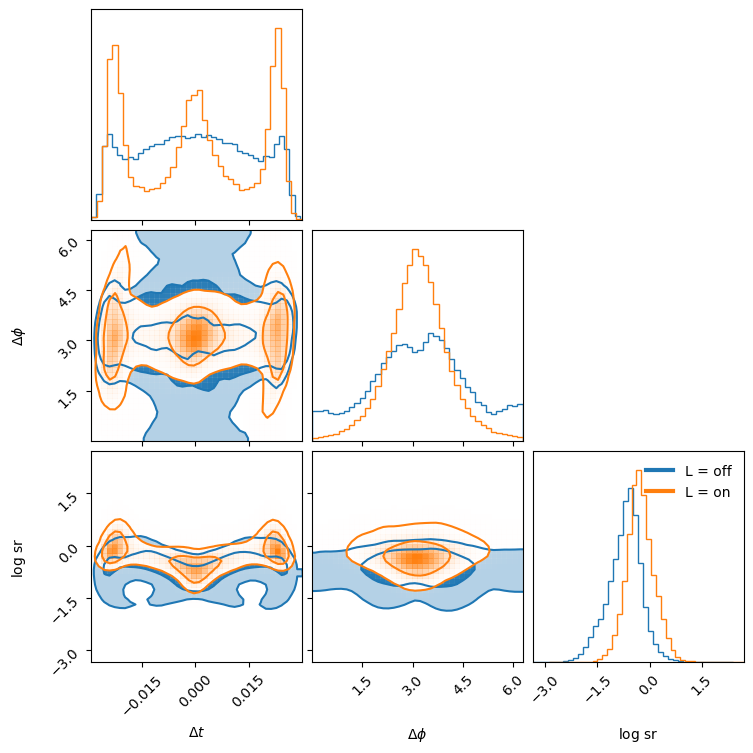

In [38]:
# --- Corner plot comparison: c = 0 vs c = 1 ---

import numpy as np
import matplotlib.pyplot as plt
import corner

from ml_stat_universal import MLStatistic

MODEL_H5 = "../../Files/DET_DEP/PHASE_TIME_AMP_L1V1_DD.h5"
N_SAMPLES = 100000  # increase for smoother contours

# ---------------------------------------------------
# Load model
# ---------------------------------------------------
ml = MLStatistic.from_file(MODEL_H5, group_name="model")
flow = ml.model
meta = ml.metadata

condition_type = meta.get("condition_type", "none")
condition_values = list(meta.get("condition_values", []))

print("Condition type:", condition_type)
print("Condition values:", condition_values)

if condition_type == "none":
    raise RuntimeError("Model is unconditional — cannot compare c=0 vs c=1.")

if not ({0.0, 1.0} <= set(condition_values)):
    raise RuntimeError("This model does not contain both c=0 and c=1.")

# ---------------------------------------------------
# Draw samples for each condition
# ---------------------------------------------------
cond0 = np.zeros((N_SAMPLES, 1))
cond1 = np.ones((N_SAMPLES, 1))

samples0 = flow.sample(N_SAMPLES, conditional=cond0)
samples1 = flow.sample(N_SAMPLES, conditional=cond1)

print("Sample shapes:", samples0.shape, samples1.shape)

# ---------------------------------------------------
# Parameter labels
# ---------------------------------------------------
n_dims = samples0.shape[1]
labels = []

for i in range(n_dims):
    if i % 3 == 0:
        labels.append(r"$\Delta t$")
    elif i % 3 == 1:
        labels.append(r"$\Delta \phi$")
    else:
        labels.append(r"$\log\,\mathrm{sr}$")

# ---------------------------------------------------
# Plot
# ---------------------------------------------------
fig = plt.figure(figsize=(8, 8))

# First condition: c = 0  (blue)
corner.corner(
    samples0,
    labels=labels,
    bins=40,
    smooth=0.9,
    color="C0",
    plot_datapoints=False,
    fill_contours=True,
    levels=(0.5, 0.9),
    alpha=0.4,
    fig=fig,
)

# Second condition: c = 1  (orange)
corner.corner(
    samples1,
    bins=40,
    smooth=0.9,
    color="C1",
    plot_datapoints=False,
    fill_contours=False,
    levels=(0.5, 0.9),
    fig=fig,
)

# Legend
handles = [
    plt.Line2D([0], [0], color="C0", lw=3, label="L = off"),
    plt.Line2D([0], [0], color="C1", lw=3, label="L = on"),
]
plt.legend(handles=handles, loc="upper right", frameon=False)

plt.show()